---
title: "Practice Activity 8.2"
format: 
    html:
        embed-resources: true
code-fold: true
echo: true
---

# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `species` using the other variables in the dataset.

**Dummify** all variables that require this.

In [1]:
# Code Here
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, precision_recall_curve
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor


In [2]:
pip install palmerpenguins

In [3]:
from palmerpenguins import load_penguins

penguins_df = load_penguins()
penguins_df.dropna(inplace=True)
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [4]:
ct = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore'),
    make_column_selector(dtype_include=object)),
    ("standardize",
    StandardScaler(),
    make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
)

Let's use the other variables to predict `species`. Prepare your data and fit the following models on the entire dataset:

* Two kNN models (for different values of K)
* Two decision tree models (for different complexities of trees)

Compute the following, for each of your models, on test data. Keep in mind that you may need to stratify your creation of the training and test data.

* Confusion matrix
* Overall Accuracy
* Precision, Recall, AUC, and F1-score for each species

Create one ROC plot for the species of your choice.

In [57]:
# Code Here
# KNN Model 1
X = penguins_df.drop(columns="species")
y = penguins_df["species"]

knn_pipeline1 = Pipeline(
  [("preprocessing", ct),
  ("knn_regressor", KNeighborsClassifier())
  ]
)
param_grid1 = {
  "knn_regressor__n_neighbors": [5]
}
gscv1 = GridSearchCV(knn_pipeline1, param_grid=param_grid1, cv = 5, scoring='r2')

In [58]:
gscv1_fit = gscv1.fit(X, y)
gscv1_fit

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/us

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('dummify',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7ef86e45d160>),
                                                                        ('standardize',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7ef86f6766f0>)])),
                                       ('knn_regressor',
                                        KNeighborsClassifier())]),
             param_grid={'knn_regressor__n_neighbors': [5]}, scoring='r2')

In [59]:
y_train_ = pd.Series(gscv1_fit.predict(X), name = "Predicted")

confusion_matrix(y, y_train_)

array([[145,   1,   0],
       [  1,  67,   0],
       [  0,   0, 119]])

In [60]:
from sklearn.metrics import classification_report

testPredictions = gscv1_fit.predict(X)
print(classification_report(y, testPredictions, digits=4))

              precision    recall  f1-score   support

      Adelie     0.9932    0.9932    0.9932       146
   Chinstrap     0.9853    0.9853    0.9853        68
      Gentoo     1.0000    1.0000    1.0000       119

    accuracy                         0.9940       333
   macro avg     0.9928    0.9928    0.9928       333
weighted avg     0.9940    0.9940    0.9940       333



In [61]:
from sklearn.metrics import roc_auc_score

testPredictionProbs = gscv1_fit.predict_proba(X)
auc_value = roc_auc_score(y, testPredictionProbs, multi_class='ovr', average='weighted')
print("Test AUC:", auc_value)

Test AUC: 0.99993152268402


In [62]:
# KNN Model 2
knn_pipeline2 = Pipeline(
  [("preprocessing", ct),
  ("knn_regressor", KNeighborsClassifier())
  ]
)
param_grid2 = {
  "knn_regressor__n_neighbors": [10]
}
gscv2 = GridSearchCV(knn_pipeline2, param_grid=param_grid2, cv = 5, scoring='r2')

In [63]:
knn_pipeline2_fit = knn_pipeline2.fit(X, y)
knn_pipeline2_fit

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ef86e45d160>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ef86f6766f0>)])),
                ('knn_regressor', KNeighborsClassifier())])

In [64]:
y_train_2 = pd.Series(knn_pipeline2_fit.predict(X), name = "Predicted")

confusion_matrix(y, y_train_2)

array([[145,   1,   0],
       [  1,  67,   0],
       [  0,   0, 119]])

In [65]:
testPredictions2 = knn_pipeline2_fit.predict(X)
print(classification_report(y, testPredictions2, digits=4))

              precision    recall  f1-score   support

      Adelie     0.9932    0.9932    0.9932       146
   Chinstrap     0.9853    0.9853    0.9853        68
      Gentoo     1.0000    1.0000    1.0000       119

    accuracy                         0.9940       333
   macro avg     0.9928    0.9928    0.9928       333
weighted avg     0.9940    0.9940    0.9940       333



In [66]:
testPredictionProbs2 = knn_pipeline2_fit.predict_proba(X)
auc_value = roc_auc_score(y, testPredictionProbs2, multi_class='ovr', average='weighted')
print("Test AUC:", auc_value)

Test AUC: 0.99993152268402


In [73]:
# Decision Tree Model 1
from sklearn.tree import DecisionTreeClassifier

X = penguins_df.drop(columns="species")
y = penguins_df["species"]

dt_model1 = DecisionTreeClassifier(max_depth=2)

dt_pipeline1 = Pipeline(
  [("preprocessing", ct),
  ("decision_tree", dt_model1)
  ]
)

dt_pipeline1.fit(X, y)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ef86e45d160>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ef86f6766f0>)])),
                ('decision_tree', DecisionTreeClassifier(max_depth=2))])

In [74]:
y_pred_dt1_test = dt_pipeline1.predict(X)

print(confusion_matrix(y, y_pred_dt1_test))

[[140   6   0]
 [  5  63   0]
 [  0   1 118]]


In [75]:
print(classification_report(y, y_pred_dt1_test, digits=4))

              precision    recall  f1-score   support

      Adelie     0.9655    0.9589    0.9622       146
   Chinstrap     0.9000    0.9265    0.9130        68
      Gentoo     1.0000    0.9916    0.9958       119

    accuracy                         0.9640       333
   macro avg     0.9552    0.9590    0.9570       333
weighted avg     0.9645    0.9640    0.9642       333



In [76]:
y_pred_proba_dt1_test = dt_pipeline1.predict_proba(X)
auc_value_dt1 = roc_auc_score(y, y_pred_proba_dt1_test, multi_class='ovr', average='weighted')
print("Test AUC:", auc_value_dt1)

Test AUC: 0.984820243831519


In [81]:
# Decision Tree Model 2
dt_model2 = DecisionTreeClassifier(max_depth=4)

dt_pipeline2 = Pipeline(
  [("preprocessing", ct),
  ("decision_tree", dt_model2)
  ]
)

dt_pipeline2.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ef86e45d160>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ef86f6766f0>)])),
                ('decision_tree', DecisionTreeClassifier(max_depth=4))])

In [82]:
y_pred_dt2_test = dt_pipeline2.predict(X)

print(confusion_matrix(y, y_pred_dt2_test))

[[146   0   0]
 [  2  66   0]
 [  0   0 119]]


In [83]:
print(classification_report(y, y_pred_dt2_test, digits=4))

              precision    recall  f1-score   support

      Adelie     0.9865    1.0000    0.9932       146
   Chinstrap     1.0000    0.9706    0.9851        68
      Gentoo     1.0000    1.0000    1.0000       119

    accuracy                         0.9940       333
   macro avg     0.9955    0.9902    0.9928       333
weighted avg     0.9941    0.9940    0.9940       333



In [84]:
y_pred_proba_dt2_test = dt_pipeline2.predict_proba(X)
auc_value_dt2 = roc_auc_score(y, y_pred_proba_dt2_test, multi_class='ovr', average='weighted')
print("Test AUC:", auc_value_dt2)

Test AUC: 0.9998219589784518


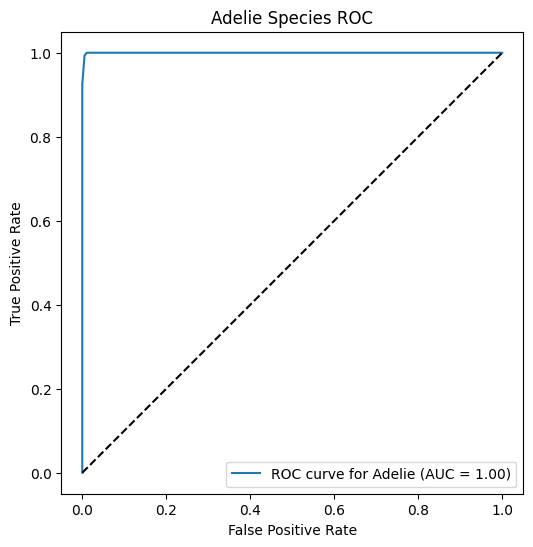

In [87]:
import matplotlib.pyplot as plt

y_pred_proba_dt2_test = dt_pipeline2.predict_proba(X)

classes = dt_pipeline2.classes_
adelie_idx = list(classes).index('Adelie')

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y == 'Adelie',
    y_pred_proba_dt2_test[:, adelie_idx],
    name=f"ROC curve for Adelie",
    ax=plt.gca()
)
plt.title("Adelie Species ROC")
plt.plot([0, 1], [0, 1], "k--")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()